## Setup and Imports

In [18]:
import os
from alphagenome.data import gene_annotation, genome, track_data, transcript
from alphagenome.models import dna_client
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set larger figure sizes for better visibility
plt.rcParams['figure.figsize'] = (16, 10)

### Load API Key and Initialize Model

In [19]:
# Load API key from environment
api_key = os.environ.get('ALPHA_GENOME_KEY')
if not api_key:
    raise ValueError("ALPHA_GENOME_KEY environment variable not set")

# Create DNA model client
dna_model = dna_client.create(api_key)
print("AlphaGenome model initialized successfully")

AlphaGenome model initialized successfully


In [20]:
# Load output metadata for human
output_metadata = dna_model.output_metadata(
    organism=dna_client.Organism.HOMO_SAPIENS
)
print("Loaded output metadata")

Loaded output metadata


### Load Gene Annotations

In [21]:
# Load local GENCODE annotations
# The AlphaGenome library expects GTF data in pandas DataFrame format
# We can either:
# 1. Use pd.read_feather if you have a .feather file
# 2. Parse the GTF file using a GTF parser library
# 3. Download the pre-processed feather file from AlphaGenome

# Option 1: Download pre-processed feather file (recommended)
print("Loading GTF annotations from AlphaGenome...")
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# Option 2: If you want to use your local GTF file, uncomment below:
# You'll need to install pyranges: pip install pyranges
# import pyranges as pr
# gtf_path = 'data/ref/gencode.v46.annotation.gtf'
# print(f"Loading GTF from {gtf_path}...")
# gtf_pr = pr.read_gtf(gtf_path)
# gtf = gtf_pr.df

# Filter to protein-coding genes and highly supported transcripts
gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf), ['1', '2']
)

# Extractor for identifying transcripts in a region
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# Also define an extractor that fetches only the longest transcript per gene
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
    gtf_transcript
)
longest_transcript_extractor = transcript.TranscriptExtractor(
    gtf_longest_transcript
)

print(f"Loaded {len(gtf)} annotations")
print(f"Filtered to {len(gtf_transcript)} protein-coding transcripts")

Loading GTF annotations from AlphaGenome...
Loaded 3467156 annotations
Filtered to 1084804 protein-coding transcripts
Loaded 3467156 annotations
Filtered to 1084804 protein-coding transcripts


## Define Variants to Analyze

Based on the variant summary data, we have the following variants:

In [22]:
# Load variant summary
variant_summary = pd.read_csv('variant_summary.csv')

# Display variants for our genes
genes_of_interest = ['GBP1', 'FCGR2B']
variants_df = variant_summary[variant_summary['gene'].isin(genes_of_interest)]

print(f"\nAnalyzing {len(variants_df)} variants:")
print(variants_df[['gene', 'pos', 'ref', 'alt', 'manuscript_name', 'priority']].drop_duplicates())


Analyzing 14 variants:
      gene        pos ref alt                   manuscript_name  priority
0     GBP1   89013380   G   A       p.Arg225Trp (GTPase domain)         2
1     GBP1   89013391   C   T       p.Arg221Gln (GTPase domain)         3
2     GBP1   89014075   T   C            c.625+8A>G (splice +8)         1
7   FCGR2B  161506414   C   T            p.Gln63* (stop-gained)         1
8   FCGR2B  161506415   A   G    p.Gln63Arg (adjacent missense)         2
11  FCGR2B  161509955   A   G  p.His167Arg (IgG binding domain)         3


In [23]:
# Define variants as genome.Variant objects
# GBP1 variants
gbp1_variants = [
    genome.Variant.from_str('chr1:89013380:G>A'),  # p.Arg225Trp (GTPase domain)
    genome.Variant.from_str('chr1:89013391:C>T'),  # p.Arg221Gln (GTPase domain)
    genome.Variant.from_str('chr1:89014075:T>C'),  # c.625+8A>G (splice +8)
]

# FCGR2B variants
fcgr2b_variants = [
    genome.Variant.from_str('chr1:161506414:C>T'),  # p.Gln63* (stop-gained)
    genome.Variant.from_str('chr1:161506415:A>G'),  # p.Gln63Arg (adjacent missense)
    genome.Variant.from_str('chr1:161509955:A>G'),  # p.His167Arg (IgG binding domain)
]

# Display variants
print("GBP1 Variants:")
for v in gbp1_variants:
    print(f"  {v}")

print("\nFCGR2B Variants:")
for v in fcgr2b_variants:
    print(f"  {v}")

GBP1 Variants:
  chr1:89013380:G>A
  chr1:89013391:C>T
  chr1:89014075:T>C

FCGR2B Variants:
  chr1:161506414:C>T
  chr1:161506415:A>G
  chr1:161509955:A>G


## Define Genomic Intervals

In [24]:
# Get gene intervals from GTF
gbp1_gene_interval = gene_annotation.get_gene_interval(gtf, gene_symbol='GBP1')
fcgr2b_gene_interval = gene_annotation.get_gene_interval(gtf, gene_symbol='FCGR2B')

# Note: AlphaGenome supports specific sequence lengths
# Supported lengths: 2KB (2,048), 16KB (16,384), 128KB (131,072), 512KB (524,288), 1MB (1,048,576)
# Using maximum context window (1MB) for both genes to capture maximum flanking regions

# Use 1MB context window for both genes
gbp1_interval = gbp1_gene_interval.resize(1_048_576)  # 1MB
fcgr2b_interval = fcgr2b_gene_interval.resize(1_048_576)  # 1MB

print(f"GBP1 interval: {gbp1_interval}")
print(f"  Width: {gbp1_interval.width:,} bp")
print(f"\nFCGR2B interval: {fcgr2b_interval}")
print(f"  Width: {fcgr2b_interval.width:,} bp")

# Extract transcripts for visualization
gbp1_transcripts = longest_transcript_extractor.extract(gbp1_interval)
fcgr2b_transcripts = longest_transcript_extractor.extract(fcgr2b_interval)

print(f"\nExtracted {len(gbp1_transcripts)} GBP1 transcripts")
print(f"Extracted {len(fcgr2b_transcripts)} FCGR2B transcripts")

GBP1 interval: chr1:88534332-89582908:-
  Width: 1,048,576 bp

FCGR2B interval: chr1:161146610-162195186:+
  Width: 1,048,576 bp

Extracted 12 GBP1 transcripts
Extracted 23 FCGR2B transcripts

Extracted 12 GBP1 transcripts
Extracted 23 FCGR2B transcripts


## Define Tissues/Cell Types

Since both genes are involved in immune response, we'll focus on immune-relevant tissues:

In [25]:
# Define ontology terms for immune-relevant tissues
immune_tissues = [
    'UBERON:0002371',  # Bone marrow
    'UBERON:0002107',  # Liver
    'CL:0000236',      # B cell
    'CL:0000084',      # T cell
]

# For broader analysis, include some general tissues
general_tissues = [
    'UBERON:0002048',  # Lung
    'UBERON:0001159',  # Sigmoid colon
]

print("Selected immune-relevant tissues for analysis")

Selected immune-relevant tissues for analysis


# GBP1 Analysis

## Gene: GBP1 (Guanylate Binding Protein 1)
- **Location**: chr1:89,011,316-89,024,677
- **Function**: GTPase involved in host defense against intracellular pathogens
- **Variants**: 3 variants including 2 missense and 1 splice region variant

### GBP1: Gene Expression Baseline

Making predictions for GBP1 expression...


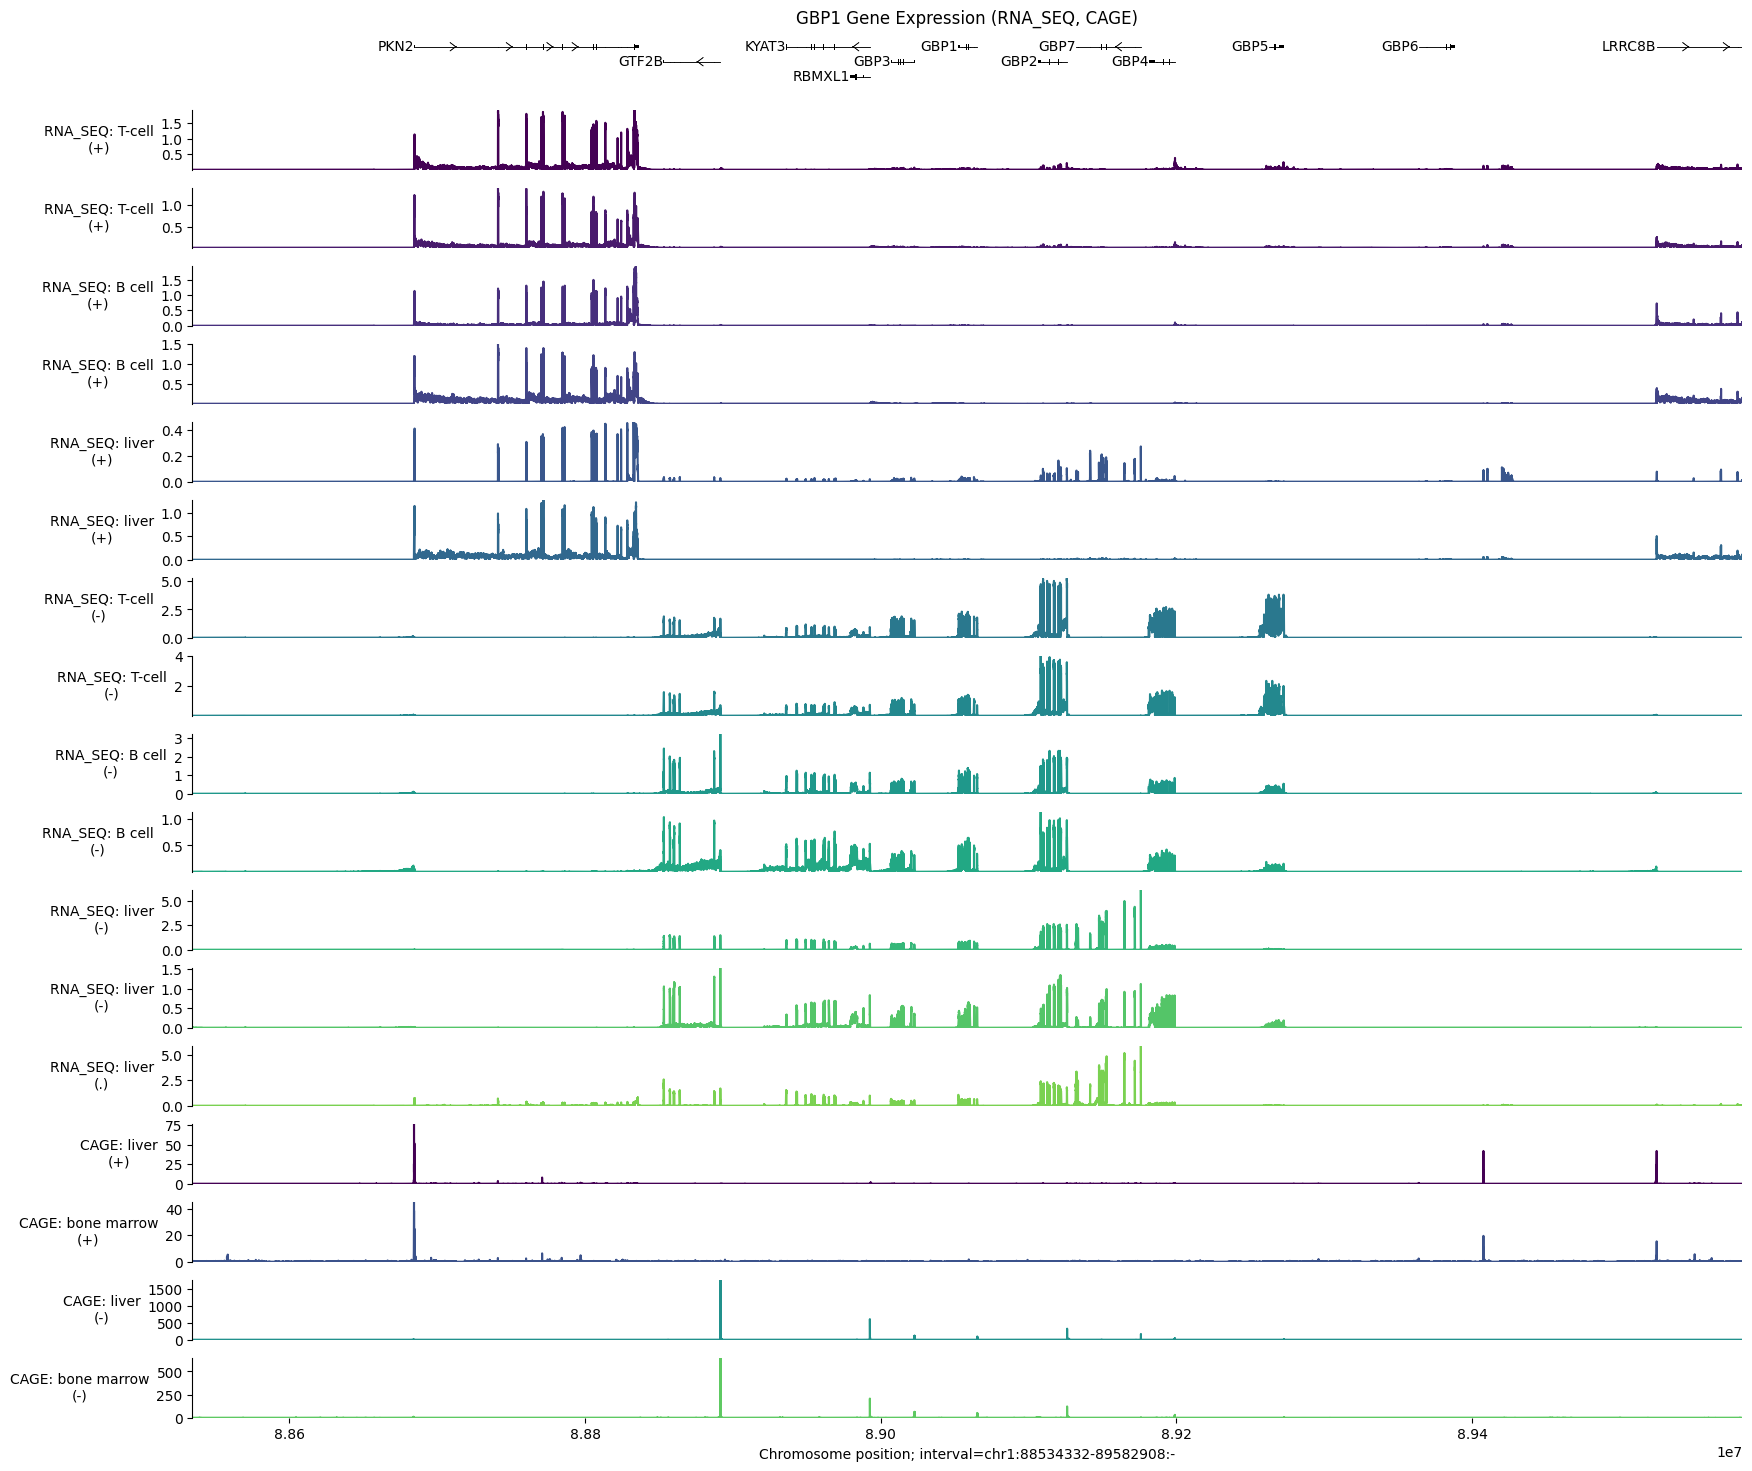

In [26]:
# Predict RNA expression for GBP1 region
print("Making predictions for GBP1 expression...")
gbp1_expression_output = dna_model.predict_interval(
    interval=gbp1_interval,
    requested_outputs={
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.CAGE,
    },
    ontology_terms=immune_tissues,
)

# Create output directory
output_dir = 'variant_analysis_results'
os.makedirs(f'{output_dir}/GBP1/expression', exist_ok=True)

# Visualize
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(gbp1_transcripts),
        plot_components.Tracks(
            tdata=gbp1_expression_output.rna_seq,
            ylabel_template='RNA_SEQ: {biosample_name}\n({strand})',
        ),
        plot_components.Tracks(
            tdata=gbp1_expression_output.cage,
            ylabel_template='CAGE: {biosample_name}\n({strand})',
        ),
    ],
    interval=gbp1_interval,
    title='GBP1 Gene Expression (RNA_SEQ, CAGE)',
)
plt.savefig(f'{output_dir}/GBP1/expression/GBP1_baseline_expression_RNA_CAGE.png', dpi=300, bbox_inches='tight')
plt.show()

### GBP1 Variant 1: chr1:89013380:G>A (p.Arg225Trp)

This missense variant affects the GTPase domain - critical for protein function.

Analyzing variant: chr1:89013380:G>A


KeyError: 'ontology_term'

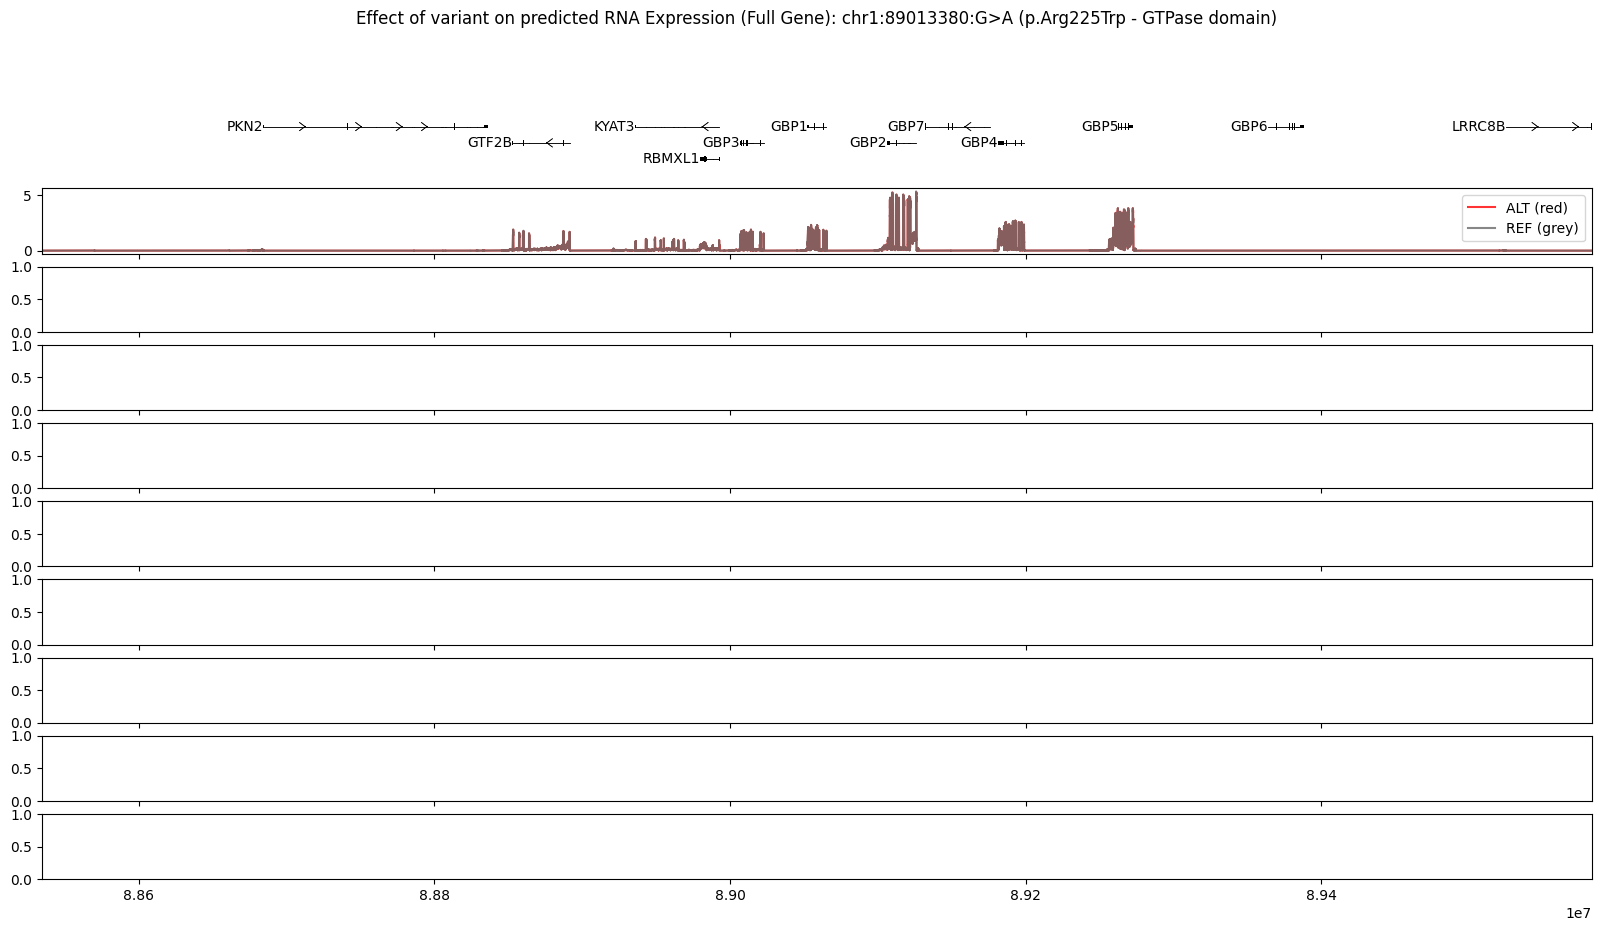

In [27]:
# Predict effects of GBP1 variant 1
print(f"Analyzing variant: {gbp1_variants[0]}")
gbp1_v1_output = dna_model.predict_variant(
    interval=gbp1_interval,
    variant=gbp1_variants[0],
    requested_outputs={
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.SPLICE_SITES,
    },
    ontology_terms=immune_tissues,
)

# Define colors for REF/ALT - make distinction very clear
ref_alt_colors = {'REF (grey)': 'dimgrey', 'ALT (red)': 'red'}

# Zoom to 20KB window around the variant for better visibility
gbp1_zoom = gbp1_variants[0].reference_interval.resize(20000)

# Create output directory
os.makedirs(f'{output_dir}/GBP1/variants', exist_ok=True)

# Visualize - UNZOOMED (full gene context)
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(gbp1_transcripts),
        # RNA-seq tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v1_output.reference.rna_seq.filter_to_nonpositive_strand(),
                'ALT (red)': gbp1_v1_output.alternate.rna_seq.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='RNA-seq: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
        # CAGE tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v1_output.reference.cage.filter_to_nonpositive_strand(),
                'ALT (red)': gbp1_v1_output.alternate.cage.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='CAGE: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
    ],
    annotations=[plot_components.VariantAnnotation([gbp1_variants[0]])],
    interval=gbp1_interval,
    title=f'Effect of variant on predicted RNA Expression (Full Gene): {gbp1_variants[0]} (p.Arg225Trp - GTPase domain)',
)
plt.savefig(f'{output_dir}/GBP1/variants/GBP1_chr1_89013380_G_A_p.Arg225Trp_GTPase_domain_UNZOOMED.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize - ZOOMED (20KB window centered on variant)
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(gbp1_transcripts),
        # RNA-seq tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v1_output.reference.rna_seq.filter_to_nonpositive_strand(),
                'ALT (red)': gbp1_v1_output.alternate.rna_seq.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='RNA-seq: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
        # CAGE tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v1_output.reference.cage.filter_to_nonpositive_strand(),
                'ALT (red)': gbp1_v1_output.alternate.cage.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='CAGE: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
    ],
    annotations=[plot_components.VariantAnnotation([gbp1_variants[0]])],
    interval=gbp1_zoom,
    title=f'Effect of variant on predicted RNA Expression (Zoomed): {gbp1_variants[0]} (p.Arg225Trp - GTPase domain)',
)
plt.savefig(f'{output_dir}/GBP1/variants/GBP1_chr1_89013380_G_A_p.Arg225Trp_GTPase_domain_ZOOMED.png', dpi=300, bbox_inches='tight')
plt.show()

### GBP1 Variant 3: chr1:89014075:T>C (Splice Region)

This variant is predicted to affect splicing (c.625+8A>G, splice +8 position).

Analyzing splice variant: chr1:89014075:T>C


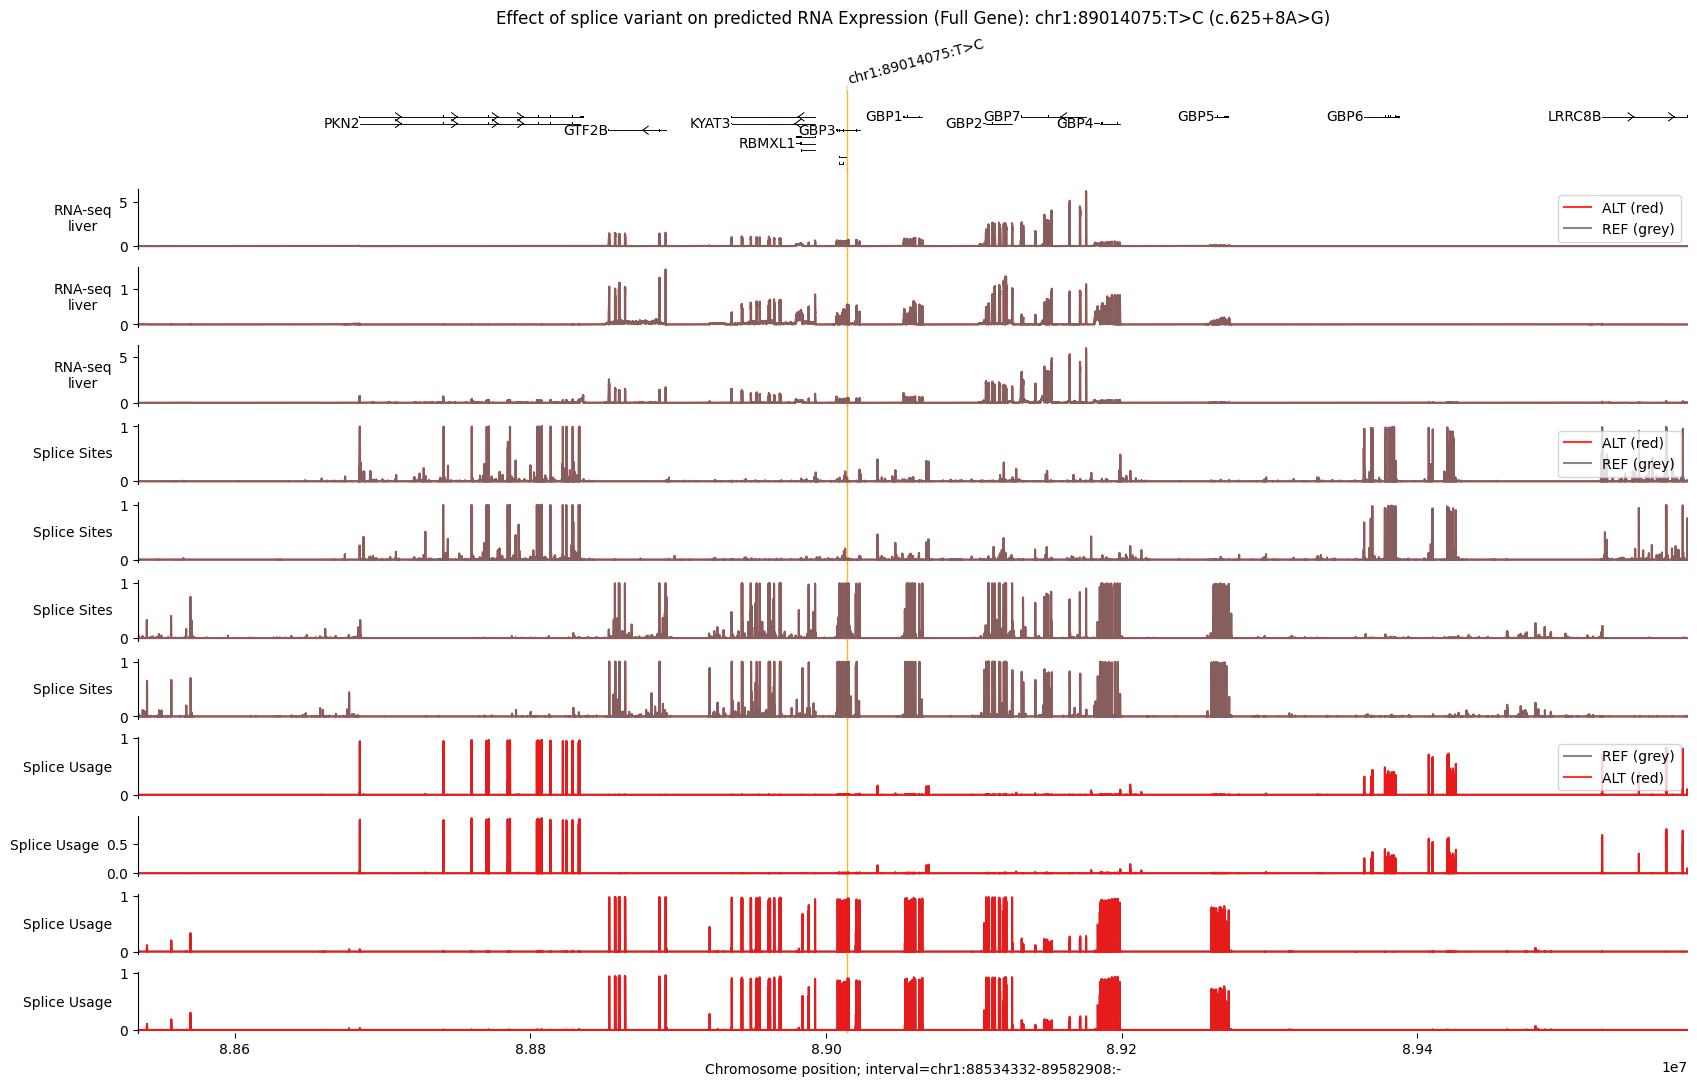

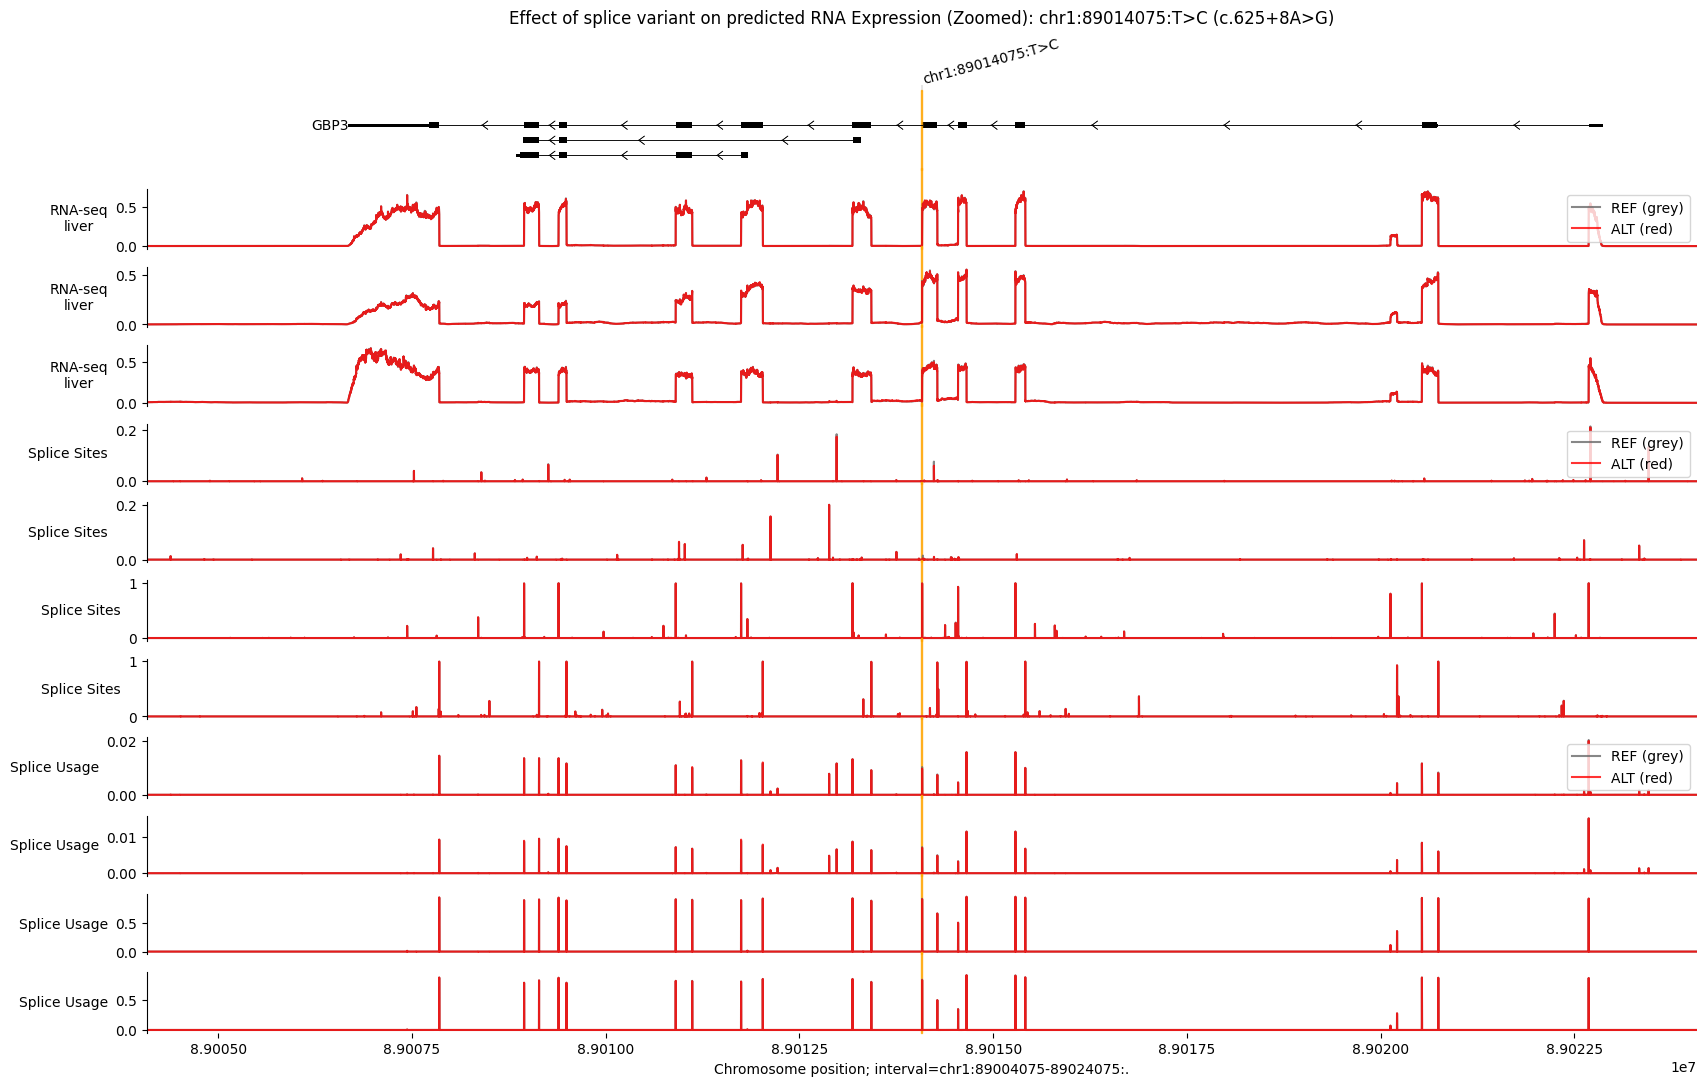


Note: Splice junction visualization omitted due to low expression in selected tissues.
Focus on splice_sites and splice_site_usage tracks for variant effects.


In [ ]:
# Predict splicing effects for GBP1 variant 3
print(f"Analyzing splice variant: {gbp1_variants[2]}")
gbp1_v3_output = dna_model.predict_variant(
    interval=gbp1_interval,
    variant=gbp1_variants[2],
    requested_outputs={
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
    },
    ontology_terms=immune_tissues[:2],  # Use subset for clarity
)

# Get all transcripts for this region
gbp1_all_transcripts = transcript_extractor.extract(gbp1_interval)

# Zoom for splice variant
gbp1_v3_zoom = gbp1_variants[2].reference_interval.resize(20000)

# Visualize - UNZOOMED (full gene context)
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(gbp1_all_transcripts),
        # RNA-seq tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v3_output.reference.rna_seq.filter_to_nonpositive_strand(),
                'ALT (red)': gbp1_v3_output.alternate.rna_seq.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='RNA-seq: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
        # Splice site tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v3_output.reference.splice_sites,
                'ALT (red)': gbp1_v3_output.alternate.splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template='Splice Sites\nREF=grey, ALT=red',
        ),
        # Splice site usage tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v3_output.reference.splice_site_usage,
                'ALT (red)': gbp1_v3_output.alternate.splice_site_usage,
            },
            colors=ref_alt_colors,
            ylabel_template='Splice Usage\nREF=grey, ALT=red',
        ),
    ],
    annotations=[plot_components.VariantAnnotation([gbp1_variants[2]])],
    interval=gbp1_interval,
    title=f'Effect of splice variant on predicted RNA Expression (Full Gene): {gbp1_variants[2]} (c.625+8A>G)',
)
plt.savefig(f'{output_dir}/GBP1/variants/GBP1_chr1_89014075_T_C_splice_region_c.625+8A_G_UNZOOMED.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize - ZOOMED (20KB window centered on variant)
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(gbp1_all_transcripts),
        # RNA-seq tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v3_output.reference.rna_seq.filter_to_nonpositive_strand(),
                'ALT (red)': gbp1_v3_output.alternate.rna_seq.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='RNA-seq: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
        # Splice site tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v3_output.reference.splice_sites,
                'ALT (red)': gbp1_v3_output.alternate.splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template='Splice Sites\nREF=grey, ALT=red',
        ),
        # Splice site usage tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': gbp1_v3_output.reference.splice_site_usage,
                'ALT (red)': gbp1_v3_output.alternate.splice_site_usage,
            },
            colors=ref_alt_colors,
            ylabel_template='Splice Usage\nREF=grey, ALT=red',
        ),
    ],
    annotations=[plot_components.VariantAnnotation([gbp1_variants[2]])],
    interval=gbp1_v3_zoom,
    title=f'Effect of splice variant on predicted RNA Expression (Zoomed): {gbp1_variants[2]} (c.625+8A>G)',
)
plt.savefig(f'{output_dir}/GBP1/variants/GBP1_chr1_89014075_T_C_splice_region_c.625+8A_G_ZOOMED.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nNote: Splice junction visualization omitted due to low expression in selected tissues.")
print("Focus on splice_sites and splice_site_usage tracks for variant effects.")

### GBP1: Chromatin Accessibility

Making predictions for GBP1 chromatin accessibility...


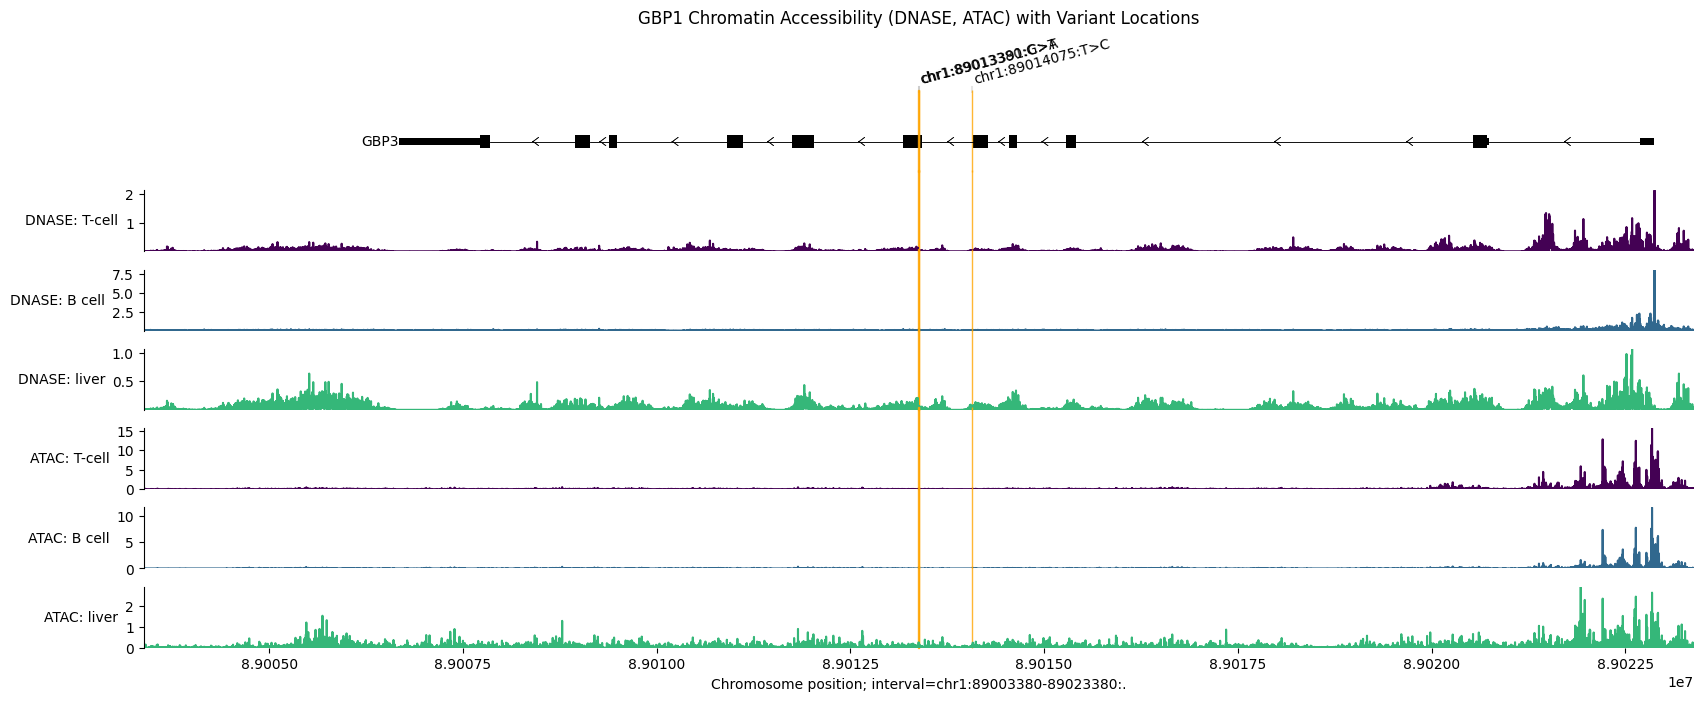

In [ ]:
# Predict chromatin accessibility for GBP1 region
print("Making predictions for GBP1 chromatin accessibility...")
gbp1_chromatin_output = dna_model.predict_interval(
    interval=gbp1_interval,
    requested_outputs={
        dna_client.OutputType.DNASE,
        dna_client.OutputType.ATAC,
    },
    ontology_terms=immune_tissues,
)

# Create output directory
os.makedirs(f'{output_dir}/GBP1/chromatin', exist_ok=True)

# Visualize with variant annotations
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(gbp1_transcripts),
        plot_components.Tracks(
            tdata=gbp1_chromatin_output.dnase,
            ylabel_template='DNASE: {biosample_name}',
        ),
        plot_components.Tracks(
            tdata=gbp1_chromatin_output.atac,
            ylabel_template='ATAC: {biosample_name}',
        ),
    ],
    interval=gbp1_zoom,
    annotations=[plot_components.VariantAnnotation(gbp1_variants)],
    title='GBP1 Chromatin Accessibility (DNASE, ATAC) with Variant Locations',
)
plt.savefig(f'{output_dir}/GBP1/chromatin/GBP1_chromatin_accessibility_DNASE_ATAC.png', dpi=300, bbox_inches='tight')
plt.show()

# FCGR2B Analysis

## Gene: FCGR2B (Fc Fragment Of IgG Receptor IIb)
- **Location**: chr1:161,505,430-161,591,342
- **Function**: Low affinity receptor for IgG, plays role in immune response regulation
- **Variants**: 3 variants including 1 nonsense (stop-gained) and 2 missense

### FCGR2B: Gene Expression Baseline

Making predictions for FCGR2B expression...


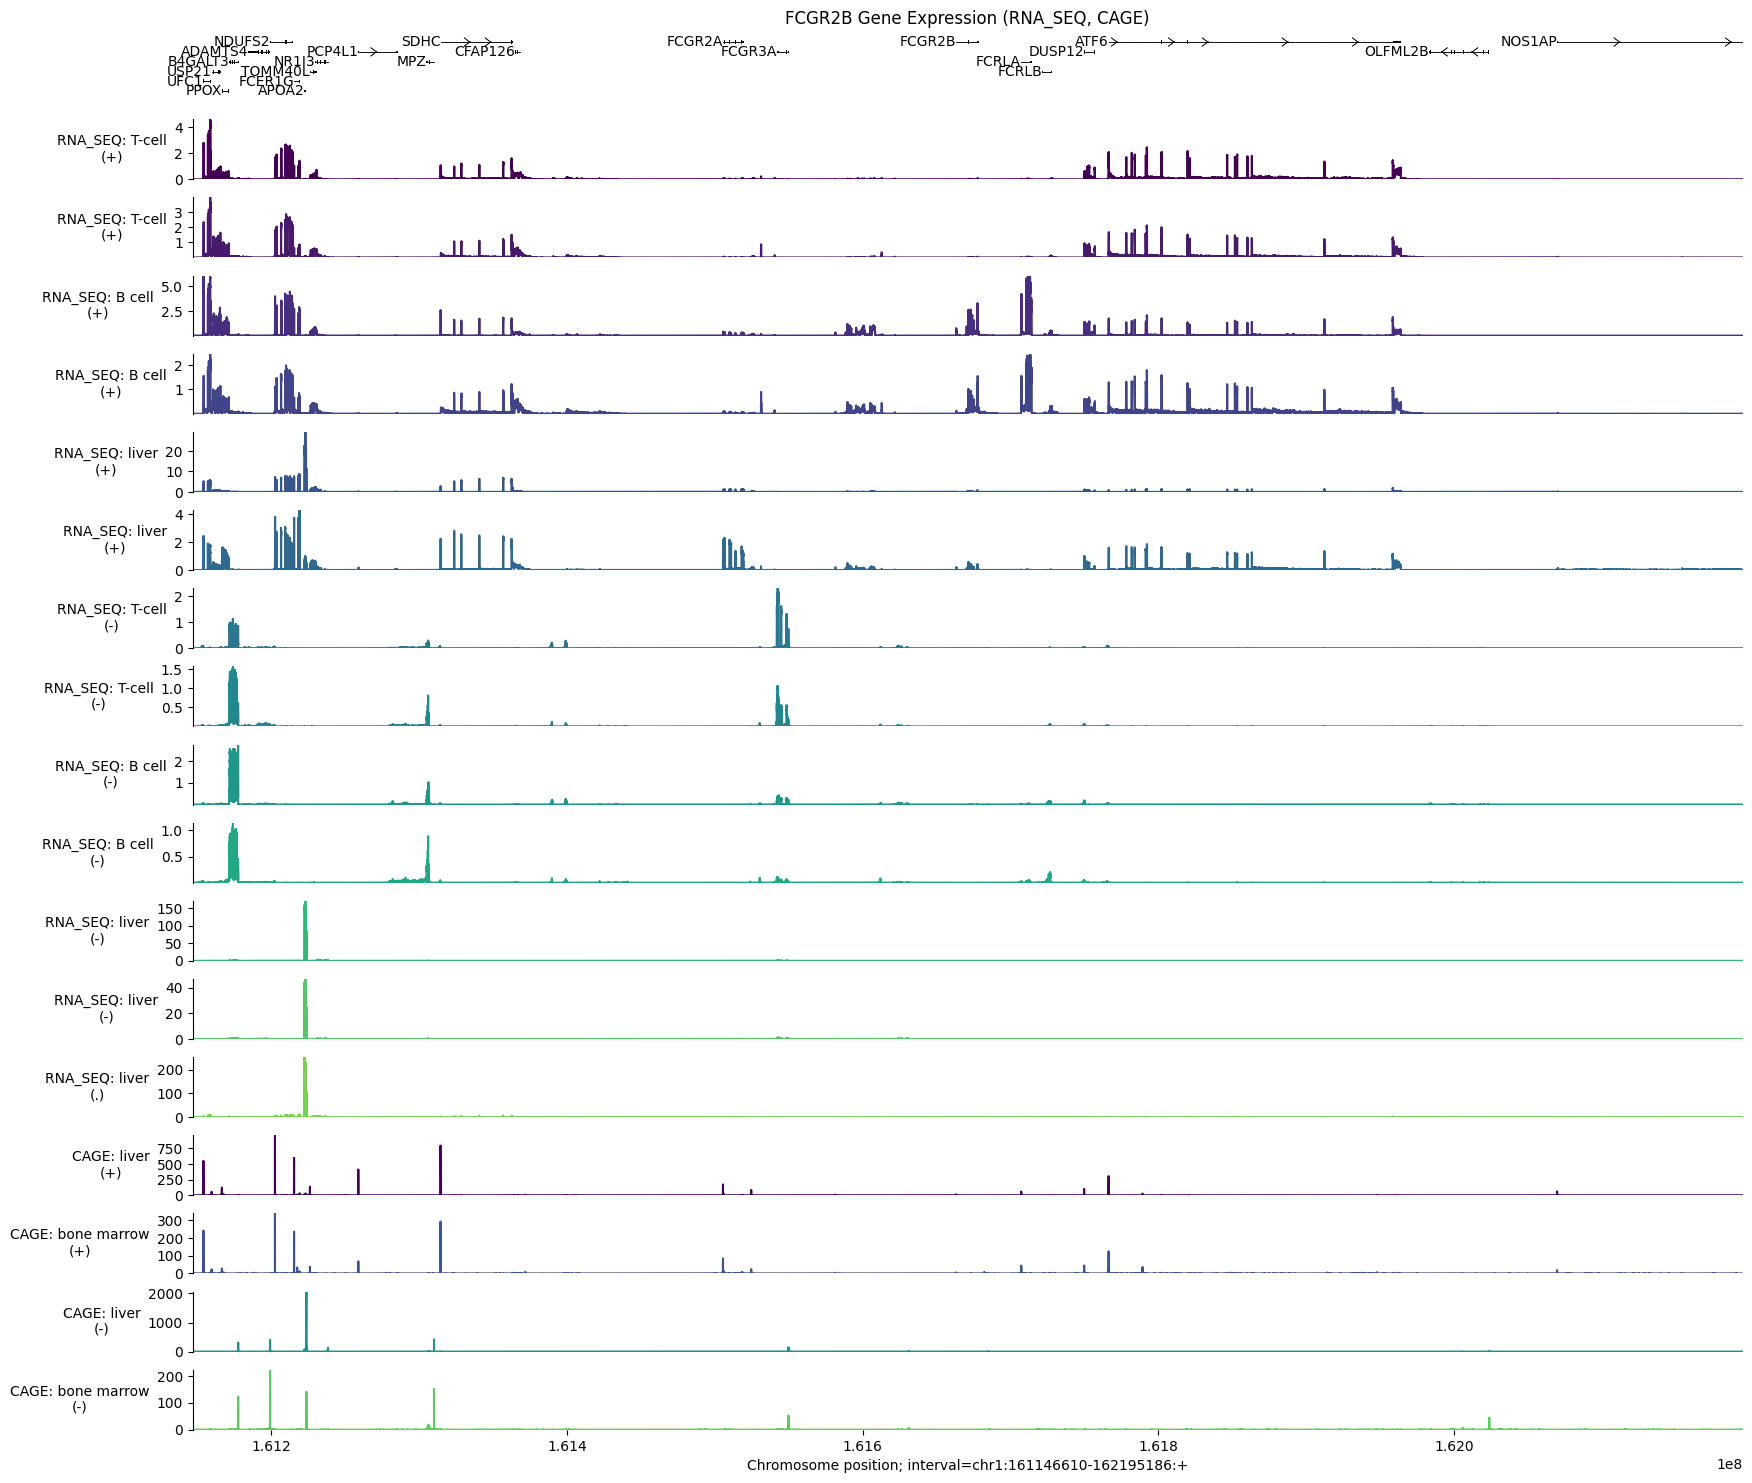

In [ ]:
# Predict RNA expression for FCGR2B region
print("Making predictions for FCGR2B expression...")
fcgr2b_expression_output = dna_model.predict_interval(
    interval=fcgr2b_interval,
    requested_outputs={
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.CAGE,
    },
    ontology_terms=immune_tissues,
)

# Create output directory
os.makedirs(f'{output_dir}/FCGR2B/expression', exist_ok=True)

# Visualize
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(fcgr2b_transcripts),
        plot_components.Tracks(
            tdata=fcgr2b_expression_output.rna_seq,
            ylabel_template='RNA_SEQ: {biosample_name}\n({strand})',
        ),
        plot_components.Tracks(
            tdata=fcgr2b_expression_output.cage,
            ylabel_template='CAGE: {biosample_name}\n({strand})',
        ),
    ],
    interval=fcgr2b_interval,
    title='FCGR2B Gene Expression (RNA_SEQ, CAGE)',
)
plt.savefig(f'{output_dir}/FCGR2B/expression/FCGR2B_baseline_expression_RNA_CAGE.png', dpi=300, bbox_inches='tight')
plt.show()

### FCGR2B Variant 1: chr1:161506414:C>T (p.Gln63* - STOP GAINED)

**Critical variant**: This introduces a premature stop codon, potentially leading to nonsense-mediated decay or truncated protein.

Analyzing stop-gained variant: chr1:161506414:C>T


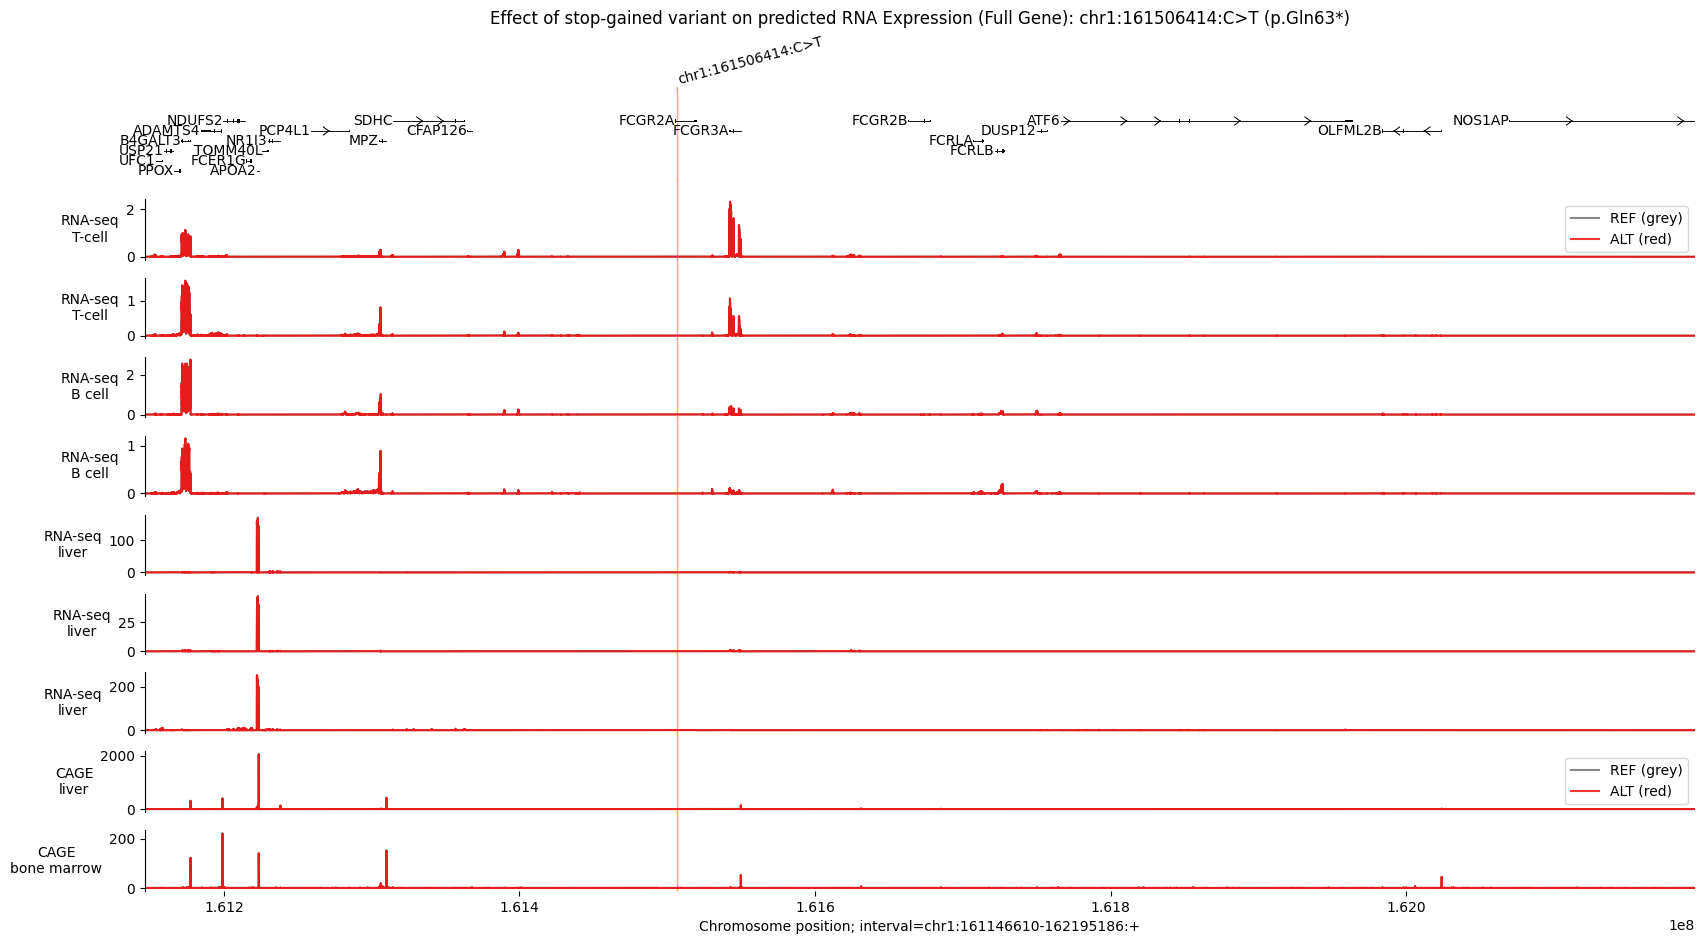

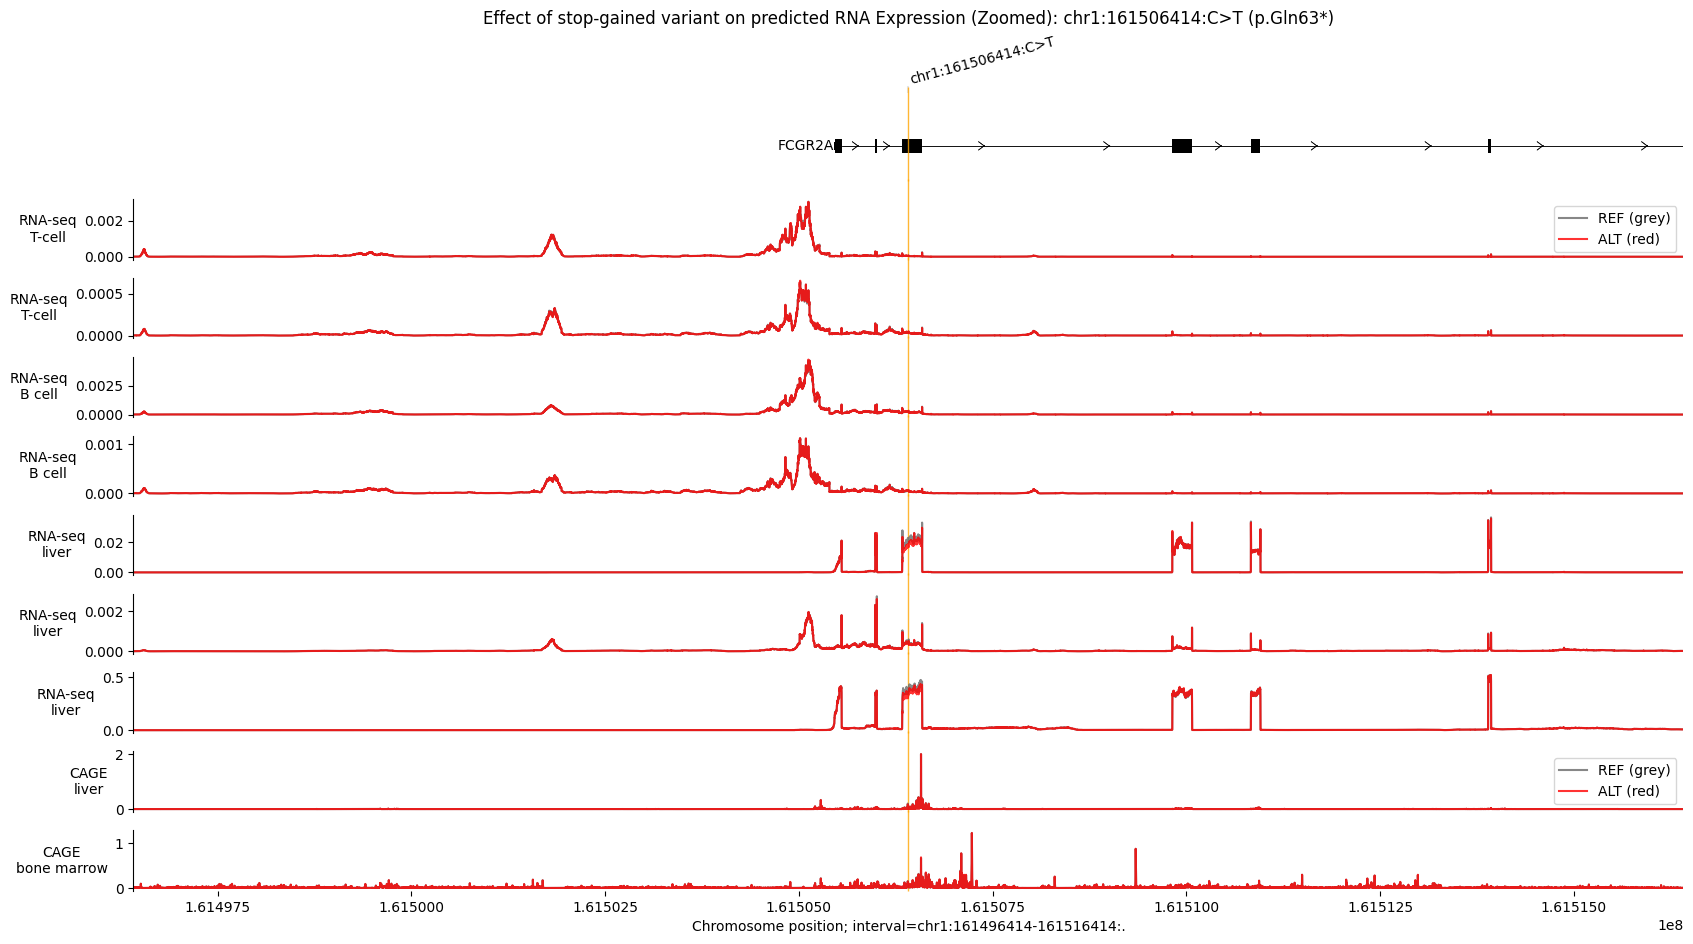


Note: This variant introduces a premature stop codon.
Look for evidence of nonsense-mediated decay (reduced ALT expression).


In [ ]:
# Predict effects of FCGR2B variant 1 (stop-gained)
print(f"Analyzing stop-gained variant: {fcgr2b_variants[0]}")
fcgr2b_v1_output = dna_model.predict_variant(
    interval=fcgr2b_interval,
    variant=fcgr2b_variants[0],
    requested_outputs={
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.SPLICE_SITES,
    },
    ontology_terms=immune_tissues,
)

# Zoom to 20KB window around the variant for better visibility
fcgr2b_zoom = fcgr2b_variants[0].reference_interval.resize(20000)

# Create output directory
os.makedirs(f'{output_dir}/FCGR2B/variants', exist_ok=True)

# Visualize - UNZOOMED (full gene context)
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(fcgr2b_transcripts),
        # RNA-seq tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v1_output.reference.rna_seq.filter_to_nonpositive_strand(),
                'ALT (red)': fcgr2b_v1_output.alternate.rna_seq.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='RNA-seq: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
        # CAGE tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v1_output.reference.cage.filter_to_nonpositive_strand(),
                'ALT (red)': fcgr2b_v1_output.alternate.cage.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='CAGE: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
    ],
    annotations=[plot_components.VariantAnnotation([fcgr2b_variants[0]])],
    interval=fcgr2b_interval,
    title=f'Effect of stop-gained variant on predicted RNA Expression (Full Gene): {fcgr2b_variants[0]} (p.Gln63*)',
)
plt.savefig(f'{output_dir}/FCGR2B/variants/FCGR2B_chr1_161506414_C_T_p.Gln63_STOP_GAINED_UNZOOMED.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize - ZOOMED (20KB window centered on variant)
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(fcgr2b_transcripts),
        # RNA-seq tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v1_output.reference.rna_seq.filter_to_nonpositive_strand(),
                'ALT (red)': fcgr2b_v1_output.alternate.rna_seq.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='RNA-seq: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
        # CAGE tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v1_output.reference.cage.filter_to_nonpositive_strand(),
                'ALT (red)': fcgr2b_v1_output.alternate.cage.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='CAGE: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
    ],
    annotations=[plot_components.VariantAnnotation([fcgr2b_variants[0]])],
    interval=fcgr2b_zoom,
    title=f'Effect of stop-gained variant on predicted RNA Expression (Zoomed): {fcgr2b_variants[0]} (p.Gln63*)',
)
plt.savefig(f'{output_dir}/FCGR2B/variants/FCGR2B_chr1_161506414_C_T_p.Gln63_STOP_GAINED_ZOOMED.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nNote: This variant introduces a premature stop codon.")
print("Look for evidence of nonsense-mediated decay (reduced ALT expression).")

### FCGR2B Variant 3: chr1:161509955:A>G (p.His167Arg - IgG Binding Domain)

This variant affects the IgG binding domain, potentially impacting receptor function.

Analyzing IgG binding domain variant: chr1:161509955:A>G


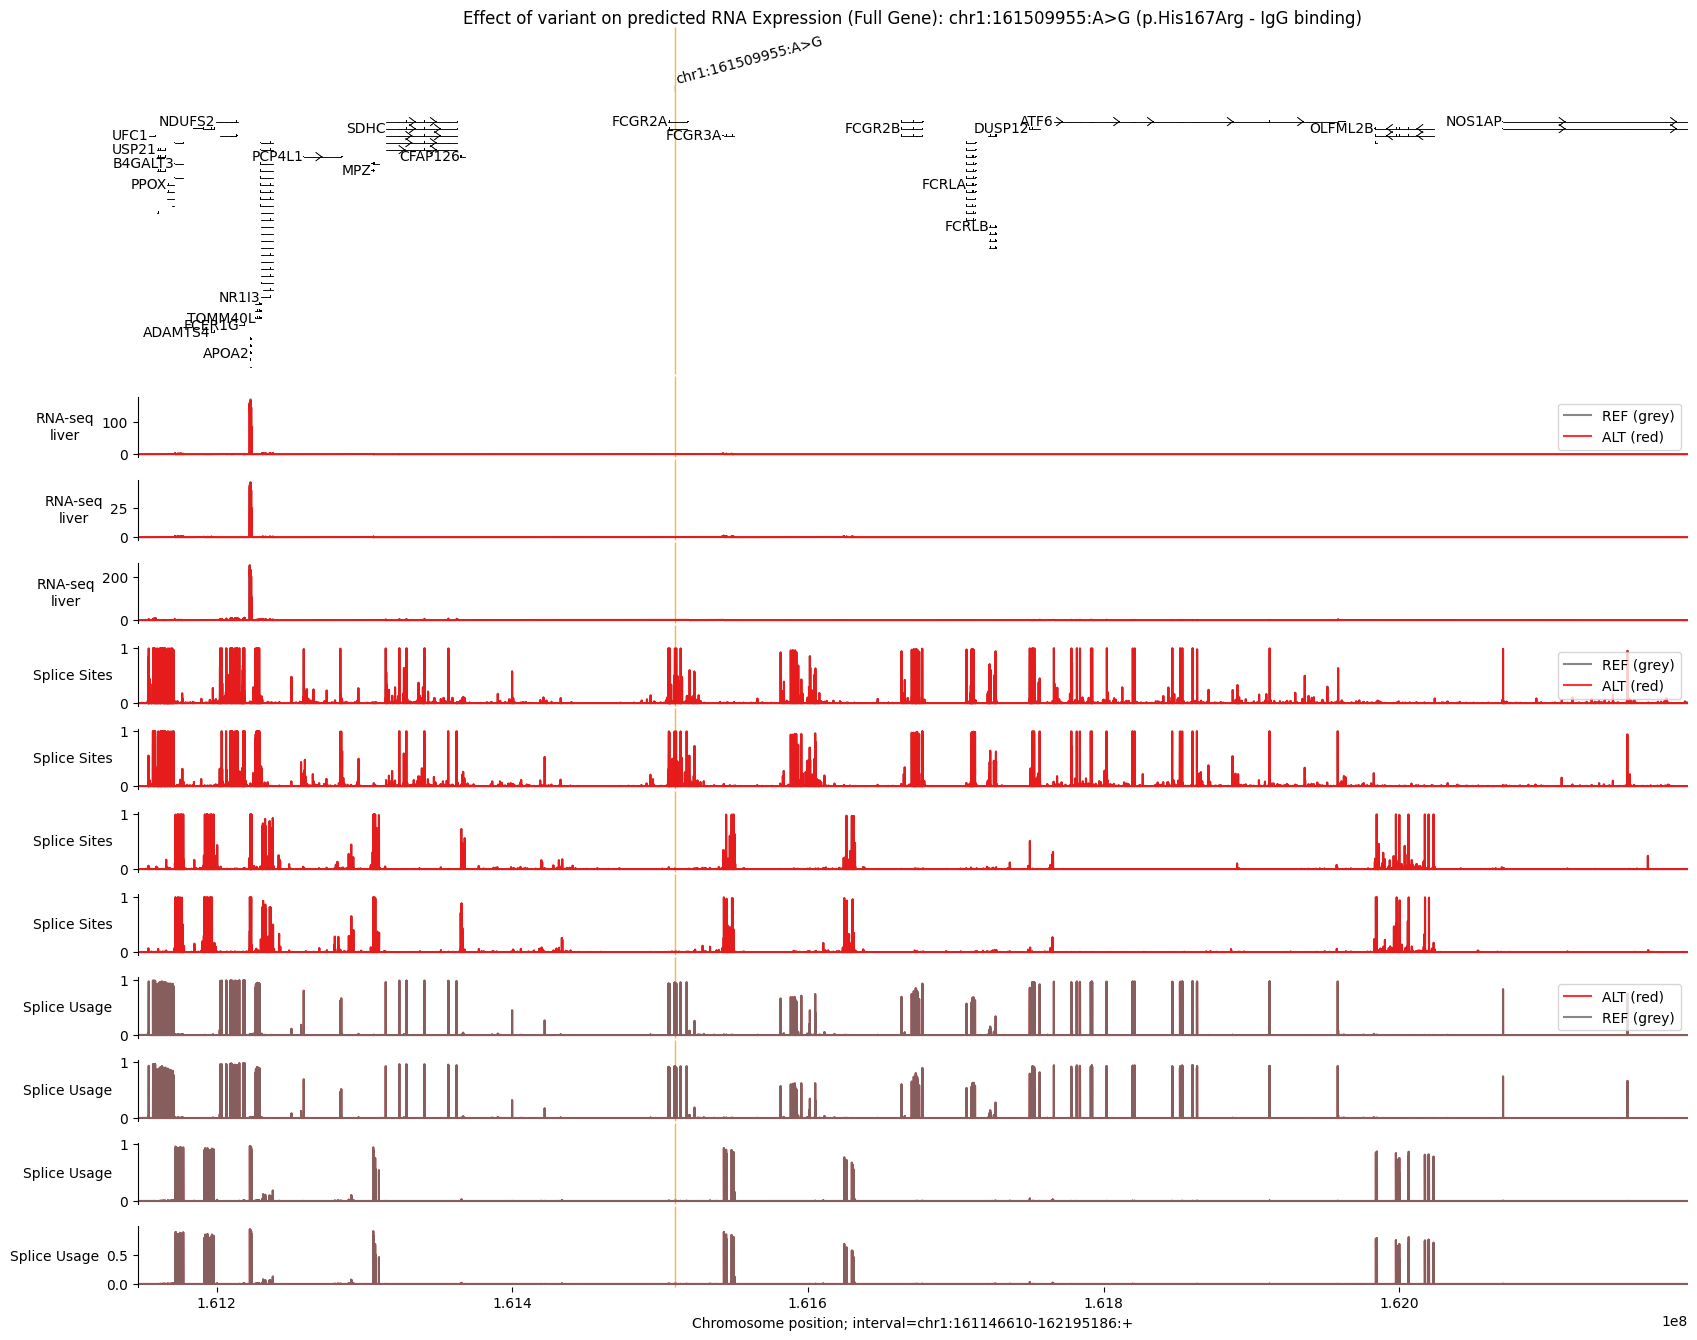

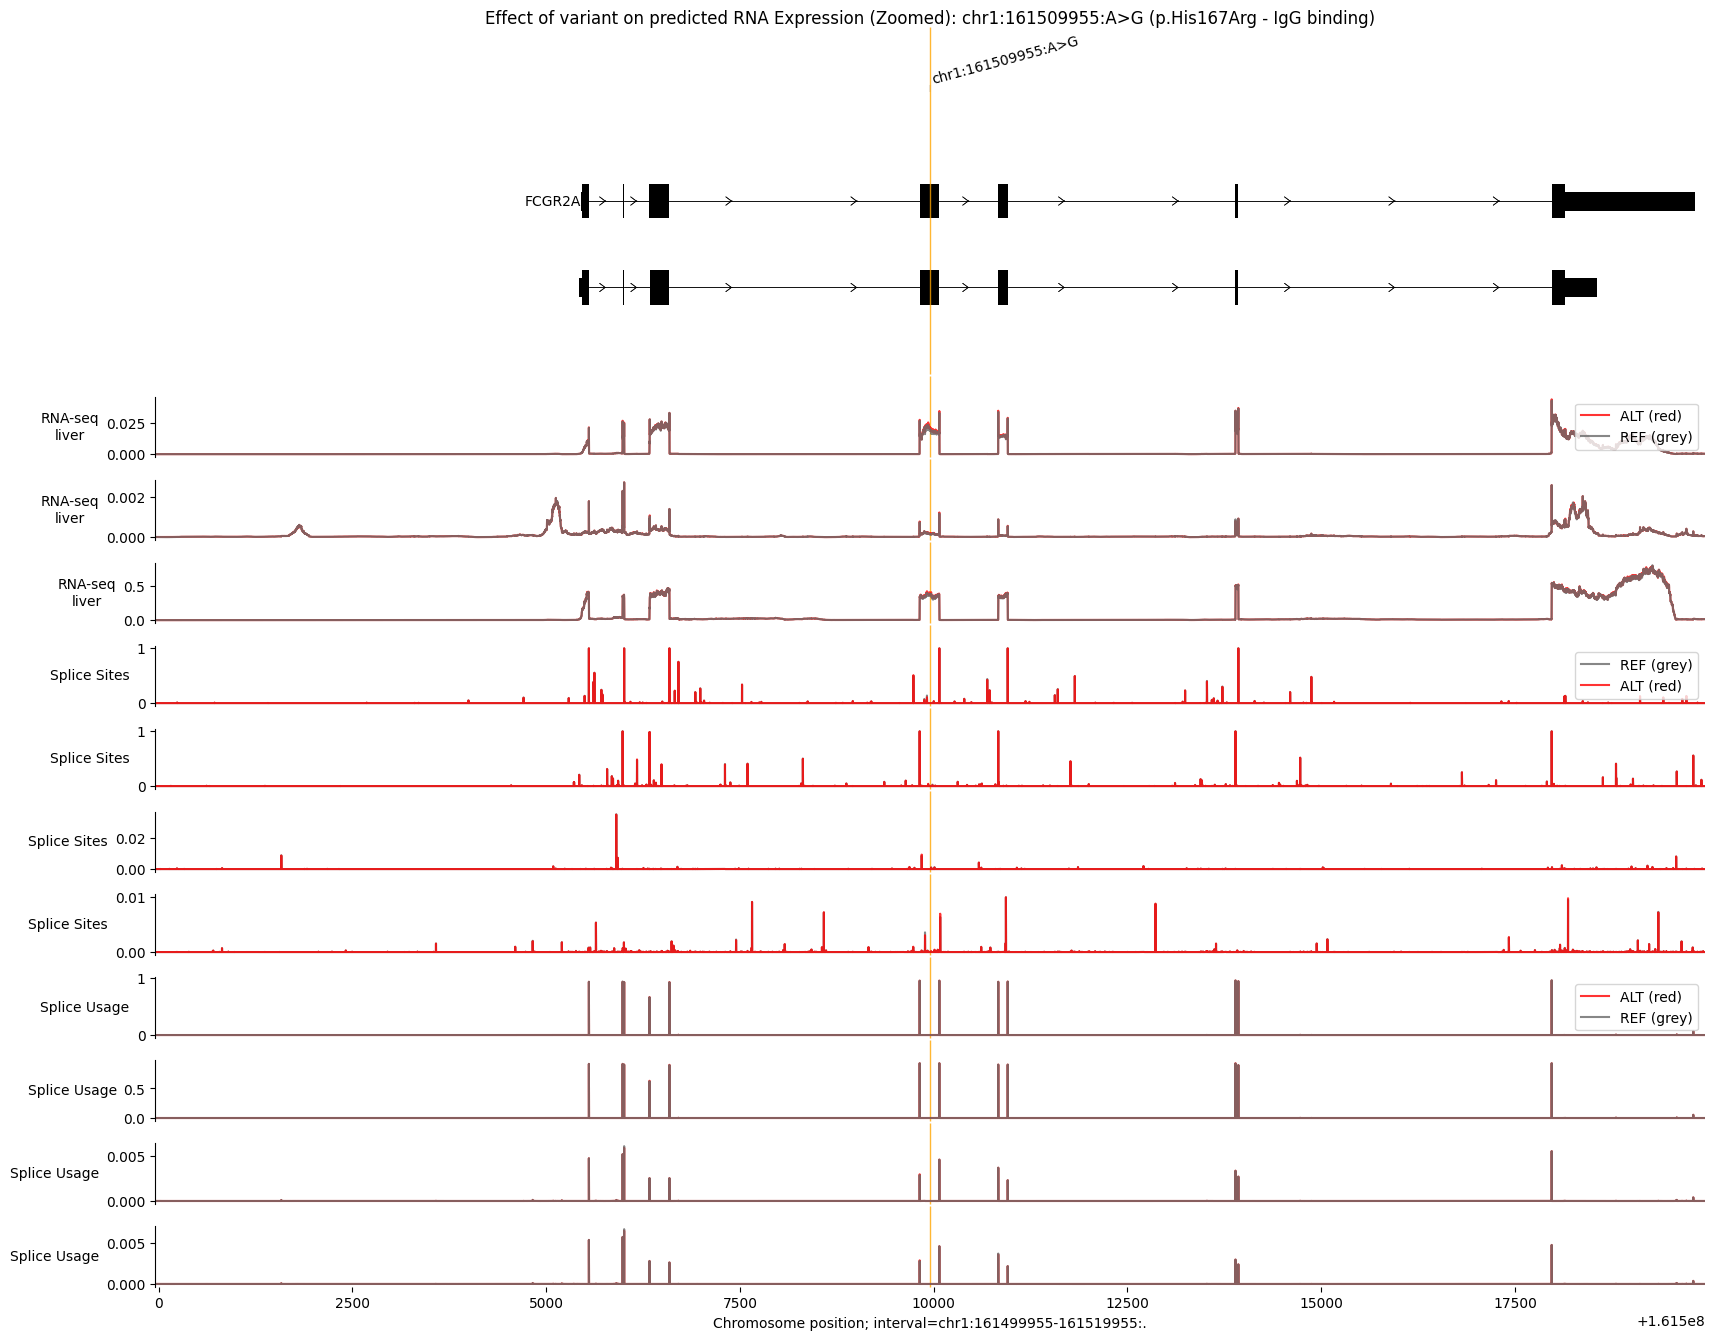


This variant is in an exon - look for any effects on splice site usage or expression.


In [ ]:
# Predict effects of FCGR2B variant 3 (IgG binding domain)
print(f"Analyzing IgG binding domain variant: {fcgr2b_variants[2]}")
fcgr2b_v3_output = dna_model.predict_variant(
    interval=fcgr2b_interval,
    variant=fcgr2b_variants[2],
    requested_outputs={
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
    },
    ontology_terms=immune_tissues[:2],
)

# Get all transcripts
fcgr2b_all_transcripts = transcript_extractor.extract(fcgr2b_interval)

# Zoom for IgG binding variant
fcgr2b_v3_zoom = fcgr2b_variants[2].reference_interval.resize(20000)

# Visualize - UNZOOMED (full gene context)
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(fcgr2b_all_transcripts),
        # RNA-seq tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v3_output.reference.rna_seq.filter_to_nonpositive_strand(),
                'ALT (red)': fcgr2b_v3_output.alternate.rna_seq.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='RNA-seq: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
        # Splice site tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v3_output.reference.splice_sites,
                'ALT (red)': fcgr2b_v3_output.alternate.splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template='Splice Sites\nREF=grey, ALT=red',
        ),
        # Splice site usage tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v3_output.reference.splice_site_usage,
                'ALT (red)': fcgr2b_v3_output.alternate.splice_site_usage,
            },
            colors=ref_alt_colors,
            ylabel_template='Splice Usage\nREF=grey, ALT=red',
        ),
    ],
    annotations=[plot_components.VariantAnnotation([fcgr2b_variants[2]])],
    interval=fcgr2b_interval,
    title=f'Effect of variant on predicted RNA Expression (Full Gene): {fcgr2b_variants[2]} (p.His167Arg - IgG binding)',
)
plt.savefig(f'{output_dir}/FCGR2B/variants/FCGR2B_chr1_161509955_A_G_p.His167Arg_IgG_binding_UNZOOMED.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize - ZOOMED (20KB window centered on variant)
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(fcgr2b_all_transcripts),
        # RNA-seq tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v3_output.reference.rna_seq.filter_to_nonpositive_strand(),
                'ALT (red)': fcgr2b_v3_output.alternate.rna_seq.filter_to_nonpositive_strand(),
            },
            colors=ref_alt_colors,
            ylabel_template='RNA-seq: {biosample_name} ({strand})\nREF=grey, ALT=red',
        ),
        # Splice site tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v3_output.reference.splice_sites,
                'ALT (red)': fcgr2b_v3_output.alternate.splice_sites,
            },
            colors=ref_alt_colors,
            ylabel_template='Splice Sites\nREF=grey, ALT=red',
        ),
        # Splice site usage tracks
        plot_components.OverlaidTracks(
            tdata={
                'REF (grey)': fcgr2b_v3_output.reference.splice_site_usage,
                'ALT (red)': fcgr2b_v3_output.alternate.splice_site_usage,
            },
            colors=ref_alt_colors,
            ylabel_template='Splice Usage\nREF=grey, ALT=red',
        ),
    ],
    annotations=[plot_components.VariantAnnotation([fcgr2b_variants[2]])],
    interval=fcgr2b_v3_zoom,
    title=f'Effect of variant on predicted RNA Expression (Zoomed): {fcgr2b_variants[2]} (p.His167Arg - IgG binding)',
)
plt.savefig(f'{output_dir}/FCGR2B/variants/FCGR2B_chr1_161509955_A_G_p.His167Arg_IgG_binding_ZOOMED.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nThis variant is in an exon - look for any effects on splice site usage or expression.")

### FCGR2B: Chromatin Accessibility

Making predictions for FCGR2B chromatin accessibility...


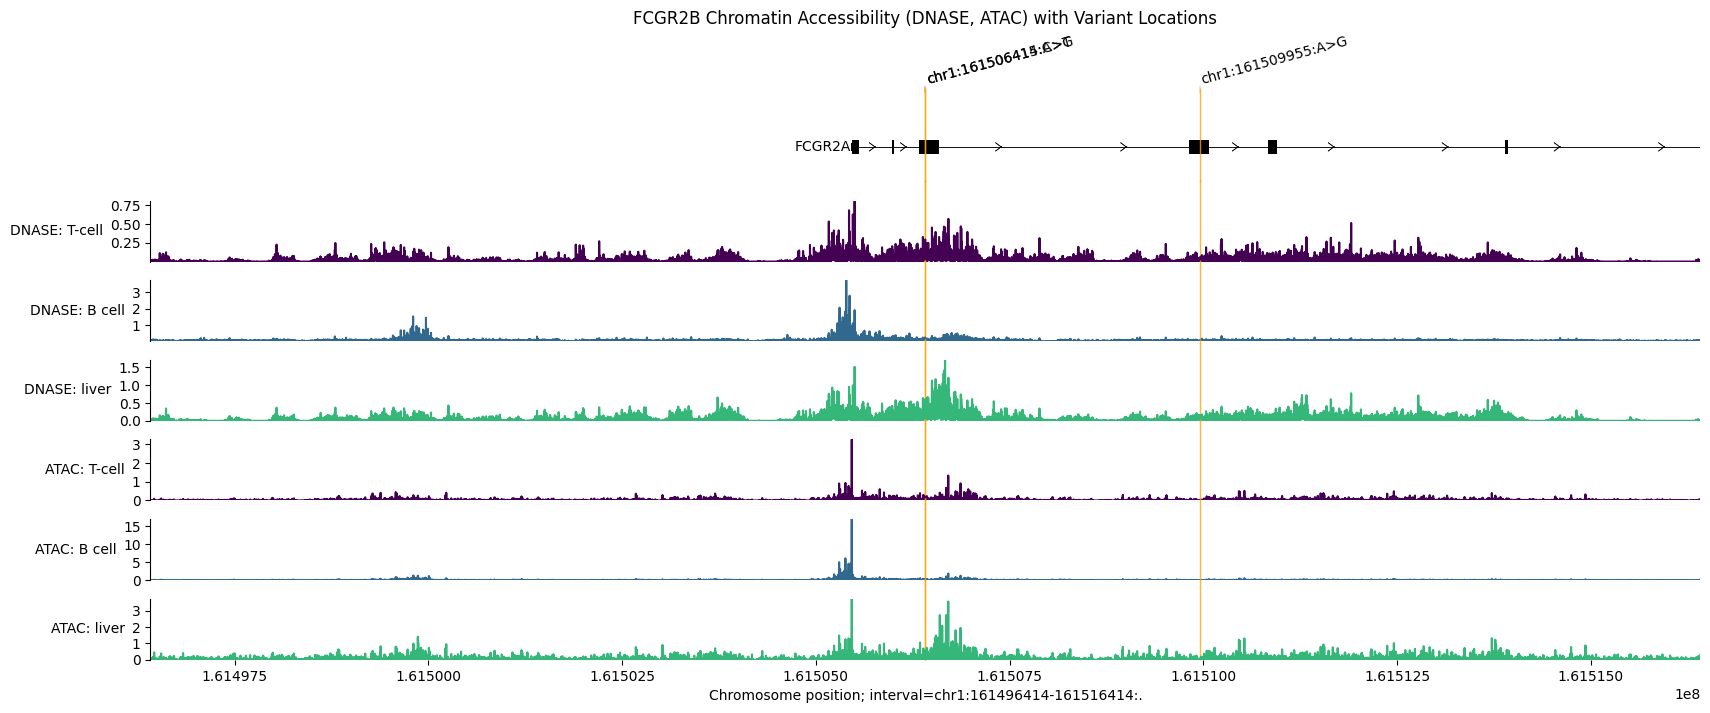

In [ ]:
# Predict chromatin accessibility for FCGR2B region
print("Making predictions for FCGR2B chromatin accessibility...")
fcgr2b_chromatin_output = dna_model.predict_interval(
    interval=fcgr2b_interval,
    requested_outputs={
        dna_client.OutputType.DNASE,
        dna_client.OutputType.ATAC,
    },
    ontology_terms=immune_tissues,
)

# Create output directory
os.makedirs(f'{output_dir}/FCGR2B/chromatin', exist_ok=True)

# Visualize with variant annotations
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(fcgr2b_transcripts),
        plot_components.Tracks(
            tdata=fcgr2b_chromatin_output.dnase,
            ylabel_template='DNASE: {biosample_name}',
        ),
        plot_components.Tracks(
            tdata=fcgr2b_chromatin_output.atac,
            ylabel_template='ATAC: {biosample_name}',
        ),
    ],
    interval=fcgr2b_zoom,
    annotations=[plot_components.VariantAnnotation(fcgr2b_variants)],
    title='FCGR2B Chromatin Accessibility (DNASE, ATAC) with Variant Locations',
)
plt.savefig(f'{output_dir}/FCGR2B/chromatin/FCGR2B_chromatin_accessibility_DNASE_ATAC.png', dpi=300, bbox_inches='tight')
plt.show()

# Comparative Analysis

## Summary of Variant Effects

### GBP1 Variants:
1. **chr1:89013380:G>A (p.Arg225Trp)**: Missense in GTPase domain
   - Expected to affect GTPase activity
   - Look for changes in expression levels and splicing patterns

2. **chr1:89013391:C>T (p.Arg221Gln)**: Missense in GTPase domain
   - Adjacent to variant 1, also in critical functional domain

3. **chr1:89014075:T>C (c.625+8A>G)**: Splice region variant
   - Affects splice donor site
   - Look for evidence of exon skipping or altered splice site usage

### FCGR2B Variants:
1. **chr1:161506414:C>T (p.Gln63*)**: **STOP-GAINED** - High impact
   - Introduces premature stop codon
   - May trigger nonsense-mediated decay
   - Potential for truncated protein with loss of function

2. **chr1:161506415:A>G (p.Gln63Arg)**: Missense adjacent to stop-gained
   - Different functional outcome than variant 1

3. **chr1:161509955:A>G (p.His167Arg)**: Missense in IgG binding domain
   - May affect receptor-ligand binding affinity
   - Known polymorphism with immune implications

## Key Observations and Next Steps

Based on the AlphaGenome predictions, examine:

1. **Expression Changes**: Compare REF vs ALT RNA-seq and CAGE signals
   - Reduced ALT expression may indicate nonsense-mediated decay
   - Changes in peak locations may indicate regulatory effects

2. **Splicing Effects**: Look for differences in:
   - Splice junction usage
   - Exon inclusion/exclusion patterns
   - Splice site strength predictions

3. **Chromatin Context**: Examine if variants fall in:
   - Accessible chromatin regions
   - Near regulatory elements
   - Regions with tissue-specific accessibility

4. **Functional Validation**: Consider:
   - Protein structure modeling for missense variants
   - Experimental validation of predicted splicing changes
   - Expression studies in relevant cell types

## Save Results

In [ ]:
# Summary of saved files
print("\n" + "="*80)
print("ANALYSIS COMPLETE - All figures saved")
print("="*80)
print(f"\nOutput directory: {output_dir}/")
print("\nDirectory structure:")
print(f"  {output_dir}/")
print("    ├── GBP1/")
print("    │   ├── expression/")
print("    │   │   └── GBP1_baseline_expression_RNA_CAGE.png")
print("    │   ├── variants/")
print("    │   │   ├── GBP1_chr1_89013380_G_A_p.Arg225Trp_GTPase_domain_UNZOOMED.png")
print("    │   │   ├── GBP1_chr1_89013380_G_A_p.Arg225Trp_GTPase_domain_ZOOMED.png")
print("    │   │   ├── GBP1_chr1_89014075_T_C_splice_region_c.625+8A_G_UNZOOMED.png")
print("    │   │   └── GBP1_chr1_89014075_T_C_splice_region_c.625+8A_G_ZOOMED.png")
print("    │   └── chromatin/")
print("    │       └── GBP1_chromatin_accessibility_DNASE_ATAC.png")
print("    └── FCGR2B/")
print("        ├── expression/")
print("        │   └── FCGR2B_baseline_expression_RNA_CAGE.png")
print("        ├── variants/")
print("        │   ├── FCGR2B_chr1_161506414_C_T_p.Gln63_STOP_GAINED_UNZOOMED.png")
print("        │   ├── FCGR2B_chr1_161506414_C_T_p.Gln63_STOP_GAINED_ZOOMED.png")
print("        │   ├── FCGR2B_chr1_161509955_A_G_p.His167Arg_IgG_binding_UNZOOMED.png")
print("        │   └── FCGR2B_chr1_161509955_A_G_p.His167Arg_IgG_binding_ZOOMED.png")
print("        └── chromatin/")
print("            └── FCGR2B_chromatin_accessibility_DNASE_ATAC.png")

print(f"\nTotal plots saved: 14")
print(f"  - GBP1: 7 plots (2 variants with zoomed + unzoomed views, plus baseline)")
print(f"  - FCGR2B: 7 plots (2 variants with zoomed + unzoomed views, plus baseline)")
print("\nAll figures saved at 300 DPI with tight bounding boxes.")
print("Each variant has both UNZOOMED (full gene context) and ZOOMED (20KB window) views.")


ANALYSIS COMPLETE - All figures saved

Output directory: variant_analysis_results/

Directory structure:
  variant_analysis_results/
    ├── GBP1/
    │   ├── expression/
    │   │   └── GBP1_baseline_expression_RNA_CAGE.png
    │   ├── variants/
    │   │   ├── GBP1_chr1_89013380_G_A_p.Arg225Trp_GTPase_domain_UNZOOMED.png
    │   │   ├── GBP1_chr1_89013380_G_A_p.Arg225Trp_GTPase_domain_ZOOMED.png
    │   │   ├── GBP1_chr1_89014075_T_C_splice_region_c.625+8A_G_UNZOOMED.png
    │   │   └── GBP1_chr1_89014075_T_C_splice_region_c.625+8A_G_ZOOMED.png
    │   └── chromatin/
    │       └── GBP1_chromatin_accessibility_DNASE_ATAC.png
    └── FCGR2B/
        ├── expression/
        │   └── FCGR2B_baseline_expression_RNA_CAGE.png
        ├── variants/
        │   ├── FCGR2B_chr1_161506414_C_T_p.Gln63_STOP_GAINED_UNZOOMED.png
        │   ├── FCGR2B_chr1_161506414_C_T_p.Gln63_STOP_GAINED_ZOOMED.png
        │   ├── FCGR2B_chr1_161509955_A_G_p.His167Arg_IgG_binding_UNZOOMED.png
        │   └── FC